# Kalman–Koopman State Estimation under Partial Observations

It assumes the encode → Koopman step → decode workflow from [`01_synthetic_graph.ipynb`](01_synthetic_graph.ipynb); here a Kalman–Koopman filter/smoother estimates state under partial observations.

In most training loops, `observation_masks` only gate losses. This notebook instead uses `koopman_graph.adaptation.KoopmanObserver` for **sensor-outage imputation**: reconstructing masked node features with a latent-space Kalman filter and Rauch–Tung–Striebel (RTS) smoother. For the related **forecast** Kalman-refine path, see [`21_uncertainty_quantification.ipynb`](21_uncertainty_quantification.ipynb) (`koopman_graph.uq.LatentGaussianKoopmanUQ`)—a different API and teaching goal.

**Process model (library row convention).** Per-node latents evolve as

$$z_{t+1} = z_t K^\top + w_t,\qquad w_t\sim\mathcal{N}(0,\sigma^2 I),$$

with $z_t\in\mathbb{R}^{N\times d}$. Equivalently, in column form on each node, $s^+=Ks$. On the flattened state $x=\mathrm{vec}_{\mathrm{row}}(z)$, the filter uses $A=I_N\otimes K$ (independent nodes for a dense `KoopmanOperator`). With known $K$ and matched $Q=\sigma^2 I$, the Kalman *process* step is exact and linear—not an approximate linearization.

**Observation model (honest limits).**
- Default `observation_model="latent_encode"`: optionally warm-start (or zero) masked features, encode, then keep **selected** rows of $H=I_{Nd}$ for observed node blocks. Under masks this is a selection matrix $H_t=S_t$, not full $I$. For **nonlinear** GNN encoders, `encode(impute(x))` is **heuristic** and fast. This notebook zeros unobserved inputs (`graph_diffusion_warm_start=False`).
- `observation_model="decoder_jacobian"`: EKF-style $H=\partial\mathrm{decode}/\partial z$ with **unobserved feature rows dropped**. This follows the decoder-Jacobian observation model, but is costly and only locally valid for nonlinear GNN decoders.

Here encode/decode are identity maps, so under this plant the selected measurement rows $H_t=S_t$ are **exact** latent coordinates (no sensor noise)—aside from the unmatched regularizer $R$. Observer $R$ is a small tuning covariance, not a matched measurement model. The general API remains encode-heuristic once encode/decode leave the identity.

**Related work** (not identical algorithms): Surana (2016), Koopman-based observer synthesis for control-affine input–output systems; Wu et al. (2025), Kalman-refined latent dynamics in $K^2$VAE (`paper.bib`: Surana2016, Wu2025K2VAE).

> **Primary question.** On a noisy synthetic linear plant (identity encode/decode), with a fully observed burn-in and **nested** dropout masks: does masked-node imputation RMSE rise with `drop_fraction`? Does RTS smoothing beat causal filtering **in aggregate** (not necessarily every time step vs the true plant)? Do both beat hold-last and zero-fill at high dropout?


## Method: filter vs smooth under nested dropout

Build a synthetic noisy linear plant, apply nested sensor dropout masks, and
compare Kalman–Koopman filter/smoother RMSE against hold-last and zero-fill baselines.


In [1]:
import warnings
from tqdm.std import TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)

import os

import matplotlib

if os.environ.get("PYTEST_CURRENT_TEST"):
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import torch
from torch_geometric.data import Data

from koopman_graph import (
    GNNDecoder,
    GNNEncoder,
    GraphKoopmanModel,
    GraphSnapshotSequence,
)
from koopman_graph.adaptation import KoopmanObserver

CI = bool(os.environ.get("PYTEST_CURRENT_TEST"))
STEPS = 24 if CI else 60
BURN_IN = 4 if CI else 8
DROPS = [0.1, 0.3, 0.5] if CI else [0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
PROCESS_STD = 0.05
OBS_NOISE = 1e-3
_ = torch.manual_seed(0)


## Helper functions

Notebook-local helpers used below.


In [2]:
def identity_encode(model, x_or_data, edge_index=None, edge_weight=None):
    _ = model, edge_index, edge_weight
    return x_or_data.x if isinstance(x_or_data, Data) else x_or_data

def build_plant(
    latent_dim=3,
    num_nodes=4,
    steps=STEPS,
    process_std=PROCESS_STD,
    seed=0,
):
    torch.manual_seed(seed)
    true_k = torch.diag(torch.linspace(0.92, 0.75, latent_dim))
    edge_index = torch.tensor(
        [list(range(num_nodes)), [(i + 1) % num_nodes for i in range(num_nodes)]],
        dtype=torch.long,
    )
    z = torch.randn(num_nodes, latent_dim)
    snaps, latents = [], []
    for _ in range(steps):
        snaps.append(Data(x=z.clone(), edge_index=edge_index))
        latents.append(z.clone())
        z = z @ true_k.T + process_std * torch.randn_like(z)
    seq = GraphSnapshotSequence(snaps)
    encoder = GNNEncoder(latent_dim, 8, latent_dim, num_layers=1)
    decoder = GNNDecoder(latent_dim, 8, latent_dim, num_layers=1)
    model = GraphKoopmanModel(
        encoder=encoder,
        decoder=decoder,
        latent_dim=latent_dim,
        time_step=1.0,
        koopman_parameterization="dense",
    )
    model.koopman.set_dense_matrix(true_k)
    # Teaching-only identity shim — not a supported public API pattern.
    # Production code should use real encode/decode or an explicit linear observation model.
    model.encode = lambda *a, **k: identity_encode(model, *a, **k)
    model.decoder.forward = lambda z, edge_index, edge_weight=None: z
    return model, seq, torch.stack(latents), true_k

def nested_masks(num_timesteps, num_nodes, drop_fraction, *, burn_in, seed=0):
    """Build nested miss masks from a shared Uniform[0, 1] field."""
    torch.manual_seed(seed)
    uniforms = torch.rand(num_timesteps, num_nodes)
    masks = uniforms >= drop_fraction
    masks[:burn_in] = True
    masks[:, 0] = True  # one always-on sensor (does not couple independent latents)
    return masks

def masked_sequence(seq, drop_fraction, *, burn_in=BURN_IN, seed=0):
    masks = nested_masks(
        len(seq),
        seq.num_nodes,
        drop_fraction,
        burn_in=burn_in,
        seed=seed,
    )
    return GraphSnapshotSequence(list(seq), observation_masks=masks)

def masked_node_rmse(pred_x_by_t, truth, masks, *, burn_in=BURN_IN):
    errs = []
    for t in range(burn_in, len(truth)):
        miss = ~masks[t]
        if not bool(miss.any()):
            continue
        errs.append(torch.mean((pred_x_by_t[t][miss] - truth[t][miss]) ** 2).sqrt())
    if not errs:
        return float("nan")
    return float(torch.stack(errs).mean().item())

def hold_last_fill(seq, masks):
    """Per-node hold-last fill (observed values unchanged)."""
    filled = []
    last = seq[0].x.clone()
    for t, snap in enumerate(seq):
        x = snap.x.clone()
        for n in range(seq.num_nodes):
            if masks[t, n]:
                last[n] = x[n]
            else:
                x[n] = last[n]
        filled.append(x)
    return filled

def zero_fill(seq, masks):
    filled = []
    for t, snap in enumerate(seq):
        x = snap.x.clone()
        x[~masks[t]] = 0.0
        filled.append(x)
    return filled


## Generate synthetic noisy linear plant data


In [3]:
model, full_seq, true_z, true_k = build_plant()
print("K diag:", [round(v, 4) for v in true_k.diag().tolist()])
print(f"steps={STEPS}, burn_in={BURN_IN}, process_std={PROCESS_STD}")


K diag: [0.92, 0.835, 0.75]
steps=60, burn_in=8, process_std=0.05


## Evaluate: nested dropout masks and baselines

Nested masks share one Uniform field, so higher `drop_fraction` only adds misses.
Soft checks require end ≥ start (not strict per-step monotonicity): finite samples can
show a local dip—annotate it on the curve when present.


In [4]:
observer = KoopmanObserver(
    model,
    process_noise=PROCESS_STD**2,
    observation_noise=OBS_NOISE,
    observation_model="latent_encode",
)

rows = []
for drop in DROPS:
    masked = masked_sequence(full_seq, drop)
    masks = masked.observation_masks
    assert masks is not None
    filt_seq = observer.impute(masked, use_smoother=False)
    smth_seq = observer.impute(masked, use_smoother=True)
    hold = hold_last_fill(full_seq, masks)
    zeros = zero_fill(full_seq, masks)
    row = {
        "drop": drop,
        "filter": masked_node_rmse([s.x for s in filt_seq], true_z, masks),
        "smooth": masked_node_rmse([s.x for s in smth_seq], true_z, masks),
        "hold_last": masked_node_rmse(hold, true_z, masks),
        "zero_fill": masked_node_rmse(zeros, true_z, masks),
    }
    rows.append(row)

print("drop  filter  smooth  hold_last  zero_fill")
for row in rows:
    print(
        f"{row['drop']:.1f}  {row['filter']:.4f}  {row['smooth']:.4f}  "
        f"{row['hold_last']:.4f}  {row['zero_fill']:.4f}"
    )

filter_rmses = [r["filter"] for r in rows]
smooth_rmses = [r["smooth"] for r in rows]
hold_rmses = [r["hold_last"] for r in rows]
zero_rmses = [r["zero_fill"] for r in rows]

# Soft checks aligned with the narrative (nested masks + burn-in).
# Strict per-step monotonicity is noisy; require end >= start and ranking.
assert smooth_rmses[-1] + 1e-5 >= smooth_rmses[0]
assert filter_rmses[-1] + 1e-5 >= filter_rmses[0]
assert all(s <= f + 1e-5 for s, f in zip(smooth_rmses, filter_rmses))
assert smooth_rmses[-1] < hold_rmses[-1]
assert filter_rmses[-1] < hold_rmses[-1]
assert smooth_rmses[-1] < zero_rmses[-1]


drop  filter  smooth  hold_last  zero_fill
0.1  0.0468  0.0394  0.0504  0.1051
0.2  0.0469  0.0367  0.0478  0.0949
0.3  0.0553  0.0419  0.0583  0.0974
0.4  0.0569  0.0437  0.0616  0.1021
0.5  0.0569  0.0483  0.0620  0.0990
0.6  0.0578  0.0510  0.0632  0.0983


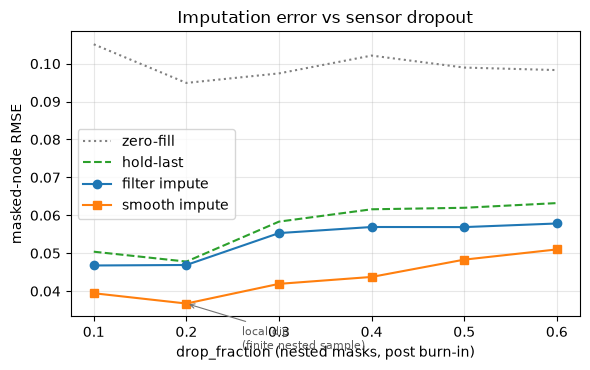

In [5]:
fig, ax = plt.subplots(figsize=(6.0, 3.8))
ax.plot(DROPS, zero_rmses, ":", color="0.5", label="zero-fill")
ax.plot(DROPS, hold_rmses, "--", color="C2", label="hold-last")
ax.plot(DROPS, filter_rmses, "o-", color="C0", label="filter impute")
ax.plot(DROPS, smooth_rmses, "s-", color="C1", label="smooth impute")
# Soft "rises overall" (end ≥ start): mark the first local dip if present.
for i in range(1, len(DROPS)):
    if smooth_rmses[i] + 1e-12 < smooth_rmses[i - 1]:
        ax.annotate(
            "local dip\n(finite nested sample)",
            xy=(DROPS[i], smooth_rmses[i]),
            xytext=(DROPS[i] + 0.06, smooth_rmses[i] - 0.012),
            fontsize=8,
            color="0.35",
            arrowprops={"arrowstyle": "->", "color": "0.45", "lw": 0.8},
        )
        break
ax.set_xlabel("drop_fraction (nested masks, post burn-in)")
ax.set_ylabel("masked-node RMSE")
ax.set_title("Imputation error vs sensor dropout")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Results: filter vs smooth at fixed dropout

At `drop_fraction=0.4`, compare causal filter vs RTS smoother after burn-in:
scalar latent RMSE and a per-step latent-error curve. RTS is model-optimal given
future observations, so **aggregate** error should improve and large spikes often
shrink—but per-step error vs the true plant need not stay ≤ filter everywhere
(process noise and unmatched \(R\)).


filter latent RMSE (t≥8): 0.0353
smooth latent RMSE (t≥8): 0.0282
per-step smooth≤filter vs truth: 34/52 (expected < all; aggregate RMSE is the claim)


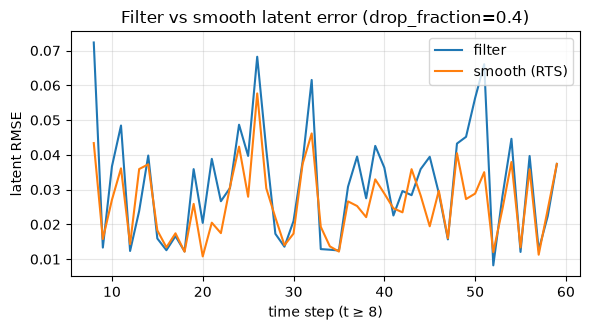

decoder_jacobian filter OK (60, 4, 3)


In [6]:
masked = masked_sequence(full_seq, drop_fraction=0.4)
filt = observer.filter(masked)
smth = observer.smooth(masked)
filt_err = torch.mean((filt.latents[BURN_IN:] - true_z[BURN_IN:]) ** 2).sqrt().item()
smth_err = torch.mean((smth.latents[BURN_IN:] - true_z[BURN_IN:]) ** 2).sqrt().item()
print(f"filter latent RMSE (t≥{BURN_IN}): {filt_err:.4f}")
print(f"smooth latent RMSE (t≥{BURN_IN}): {smth_err:.4f}")
# Teaching check is aggregate RMSE (not pointwise vs the true plant).
assert smth_err <= filt_err + 1e-5

# Per-step latent RMSE after burn-in (mean over nodes and latent dims).
t_axis = list(range(BURN_IN, len(true_z)))
filt_step = (
    ((filt.latents[BURN_IN:] - true_z[BURN_IN:]) ** 2).mean(dim=(1, 2)).sqrt().tolist()
)
smth_step = (
    ((smth.latents[BURN_IN:] - true_z[BURN_IN:]) ** 2).mean(dim=(1, 2)).sqrt().tolist()
)
n_le = sum(s <= f + 1e-12 for f, s in zip(filt_step, smth_step))
print(
    f"per-step smooth≤filter vs truth: {n_le}/{len(filt_step)} "
    "(expected < all; aggregate RMSE is the claim)"
)
fig, ax = plt.subplots(figsize=(6.0, 3.4))
ax.plot(t_axis, filt_step, "-", color="C0", label="filter")
ax.plot(t_axis, smth_step, "-", color="C1", label="smooth (RTS)")
ax.set_xlabel(f"time step (t ≥ {BURN_IN})")
ax.set_ylabel("latent RMSE")
ax.set_title("Filter vs smooth latent error (drop_fraction=0.4)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Identity decode ⇒ local H ≈ I before row selection (keep the quick demo light).
jac_observer = KoopmanObserver(
    model,
    process_noise=PROCESS_STD**2,
    observation_noise=OBS_NOISE,
    observation_model="decoder_jacobian",
)
jac = jac_observer.filter(masked_sequence(full_seq, 0.3))
assert torch.isfinite(jac.latents).all()
print("decoder_jacobian filter OK", tuple(jac.latents.shape))


## Takeaways

1. For fixed dense `K`, the latent **process** model is exactly linear (`z ← z Kᵀ + w` / `A = I ⊗ K`). On **this** identity encode/decode plant, selected rows $H_t=S_t$ are exact latent measurements (aside from unmatched $R$). In the general API, `latent_encode` is encode-heuristic for nonlinear GNNs, and `decoder_jacobian` is only EKF-local—not an exact Kalman filter in feature space for nonlinear decoders.
2. With nested masks, process noise, and a fully observed burn-in, masked-node RMSE **rises overall** with `drop_fraction` (end ≥ start; small local dips can occur from finite nested-mask samples—see the annotated curve).
3. RTS smoothing improves on causal filtering in **aggregate** (lower latent RMSE; the per-step curve often cuts large spikes, though not every step beats the filter vs the true plant); both beat hold-last and zero-fill at high dropout.
4. Prefer `latent_encode` for large graphs and notebooks; use `decoder_jacobian` when you need the decoder-Jacobian observation model and can afford the Jacobian cost.

## Next steps

- See [`17_delay_embedding_partial_observability.ipynb`](17_delay_embedding_partial_observability.ipynb) for delay stacking under missing sensors.
- See [`21_uncertainty_quantification.ipynb`](21_uncertainty_quantification.ipynb) for forecast UQ: ensembles and `LatentGaussianKoopmanUQ` (Kalman-refine peer; distinct from this notebook’s `KoopmanObserver` imputation path).
- See [`01_synthetic_graph.ipynb`](01_synthetic_graph.ipynb) for the base workflow.
- Explore the [API reference](https://koopmangraph.readthedocs.io/en/latest/api.html).
